In [1]:
import pandas as pd

nav = pd.read_csv("data/processed/clean_nav.csv")

print(nav.shape)
print(nav.head())

print(nav["amfi_code"].nunique())

print(nav["date"].min())
print(nav["date"].max())

(46000, 3)
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
40
2022-01-03
2026-05-29


In [7]:
pip install kaleido

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


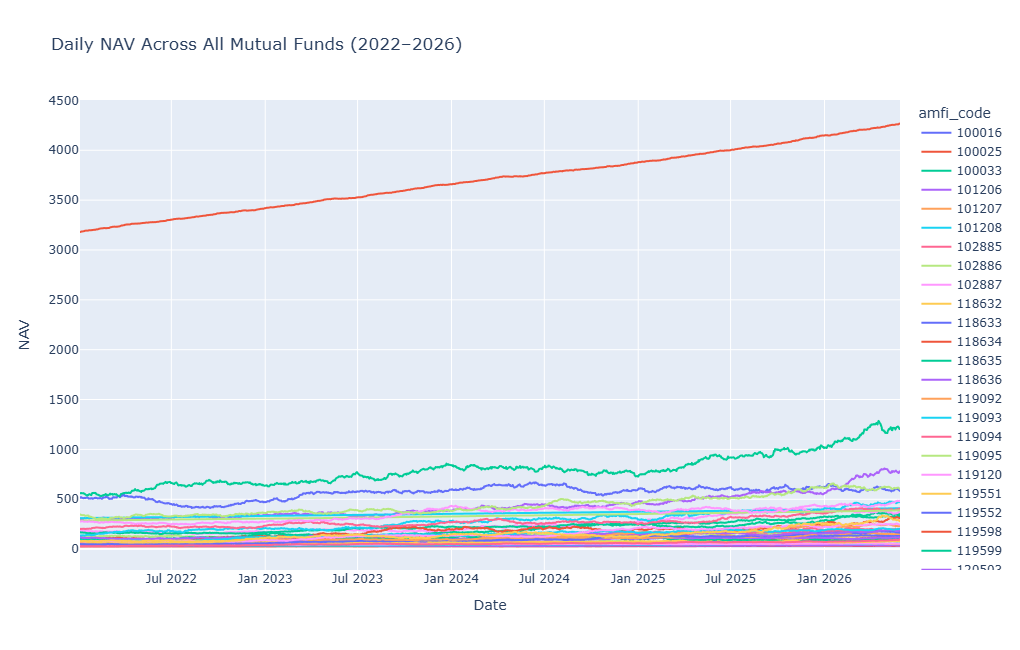

In [3]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Across All Mutual Funds (2022–2026)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    height=650
)

fig.show()
fig.write_image(
    "reports/charts/nav_trend_line_all.png"
)

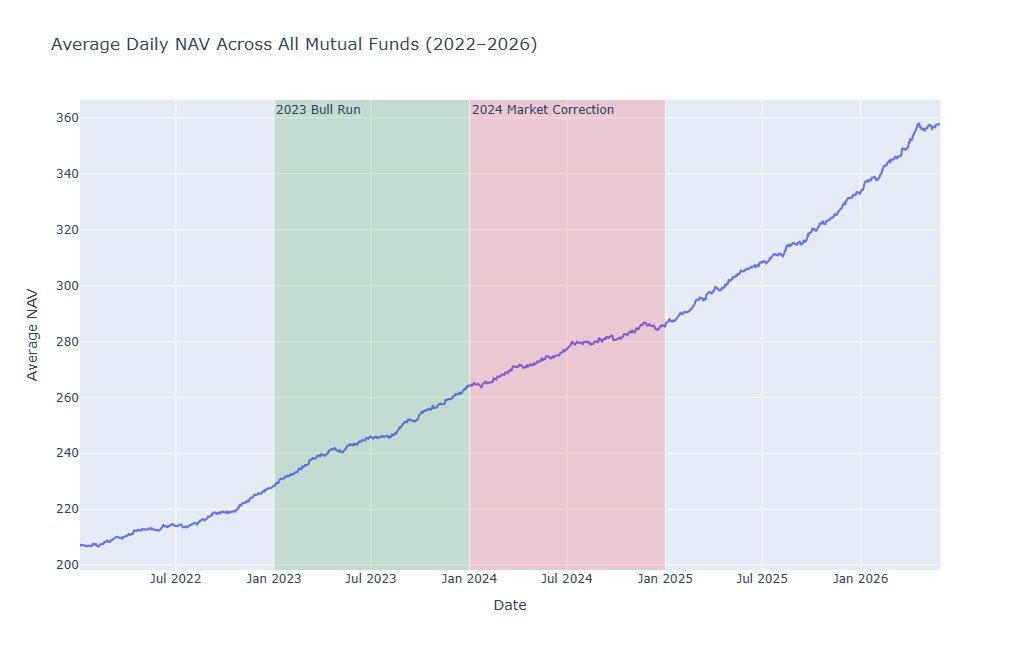

In [4]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

avg_nav = (
    nav.groupby("date")["nav"]
    .mean()
    .reset_index()
)

fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Across All Mutual Funds (2022–2026)"
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    line_width=0
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average NAV",
    height=650
)

fig.show()
fig.write_image(
    "reports/charts/Highlight_avg_nav_trend.png"
)

In [5]:
import pandas as pd

aum = pd.read_csv("data/processed/clean_aum_by_fund_house.csv")

print(aum.shape)
print(aum.head())

print("\nColumns:")
print(aum.columns)

print("\nDate Range:")
print(aum["date"].min())
print(aum["date"].max())

print("\nFund Houses:")
print(aum["fund_house"].nunique())

(90, 5)
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

Date Range:
2022-03-31
2025-12-31

Fund Houses:
10


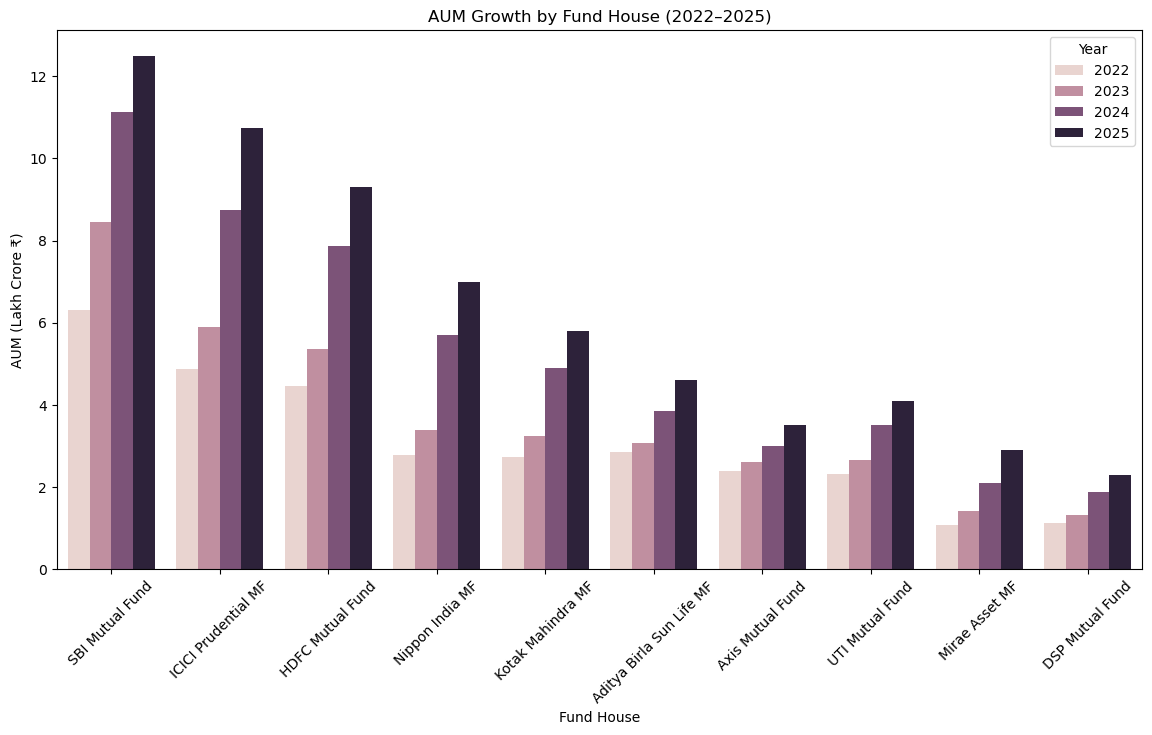

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("data/processed/clean_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

latest_dates = (
    aum.groupby("year")["date"]
    .max()
    .reset_index()
)

aum_yearly = aum.merge(
    latest_dates,
    on=["year", "date"]
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=45)
plt.legend(title="Year")

plt.show()

In [5]:
import pandas as pd

sip = pd.read_csv(
    "data/processed/clean_monthly_sip_inflows.csv"
)

print(sip.shape)
print(sip.head())

print("\nColumns:")
print(sip.columns)

print("\nDate Range:")
print(sip["month"].min())
print(sip["month"].max())

print("\nMaximum SIP Inflow:")
print(sip["sip_inflow_crore"].max())

(48, 6)
        month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01-01             11517                       4.91   
1  2022-02-01             11438                       4.93   
2  2022-03-01             12328                       5.09   
3  2022-04-01             11863                       5.48   
4  2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

Date Range:
2022-01-01
2025-12-01

Maximum SIP Inflow:
31002


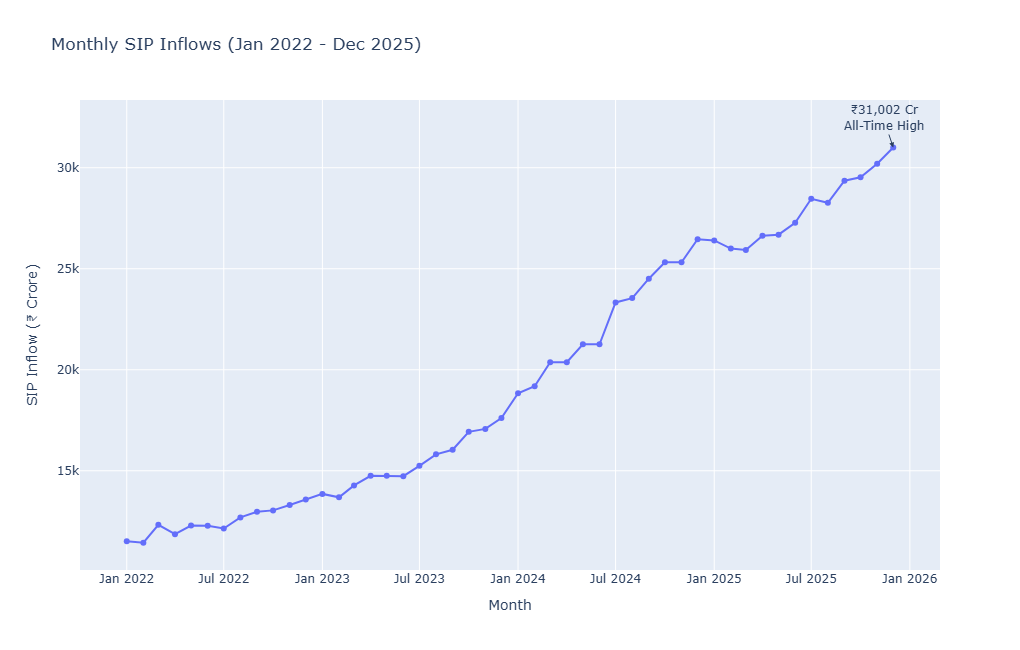

In [7]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv(
    "data/processed/clean_monthly_sip_inflows.csv"
)

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)"
)

# Highlight Dec 2025 Peak
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    height=650
)

fig.show()
fig.write_image(
    "reports/charts/sip_inflow_trend.png"
)

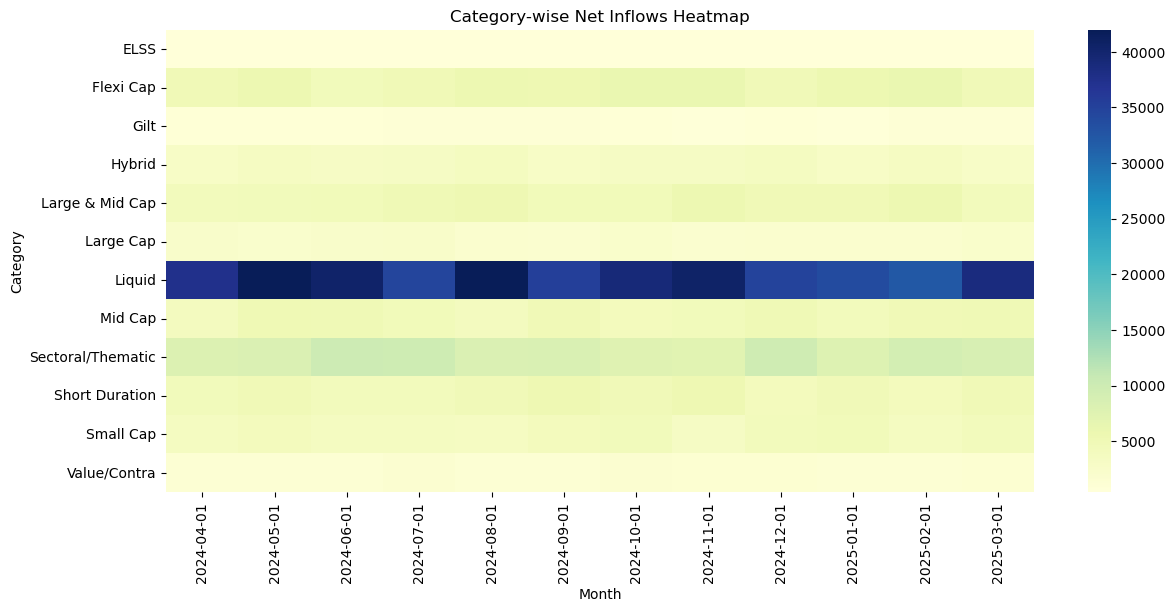

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv(
    "data/processed/clean_category_inflows.csv"
)

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [10]:
import pandas as pd

trans = pd.read_csv(
    "data/processed/clean_transactions.csv"
)

print(trans.shape)
print(trans.columns)

print("\nAge Groups:")
print(trans["age_group"].value_counts())

print("\nGender:")
print(trans["gender"].value_counts())

print("\nCity Tier:")
print(trans["city_tier"].value_counts())

(32778, 13)
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Age Groups:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64

City Tier:
city_tier
T30    21719
B30    11059
Name: count, dtype: int64


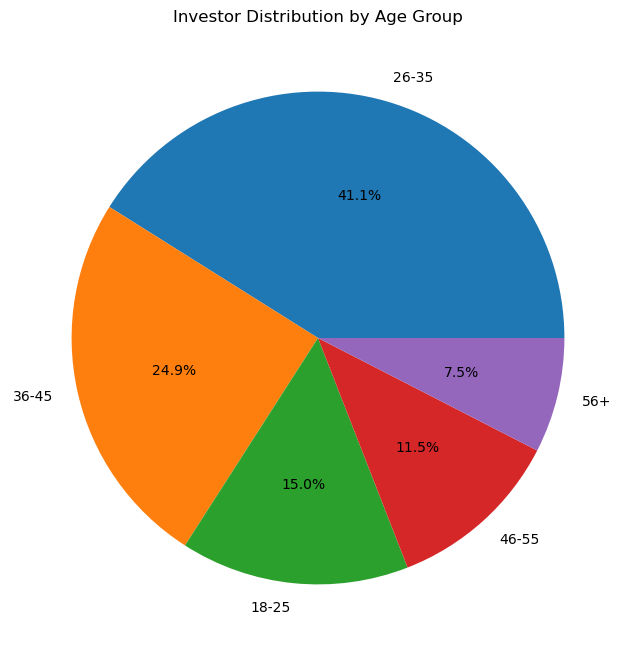

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

trans = pd.read_csv(
    "data/processed/clean_transactions.csv"
)

age_counts = trans["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by Age Group")

plt.savefig(
    "reports/charts/06_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

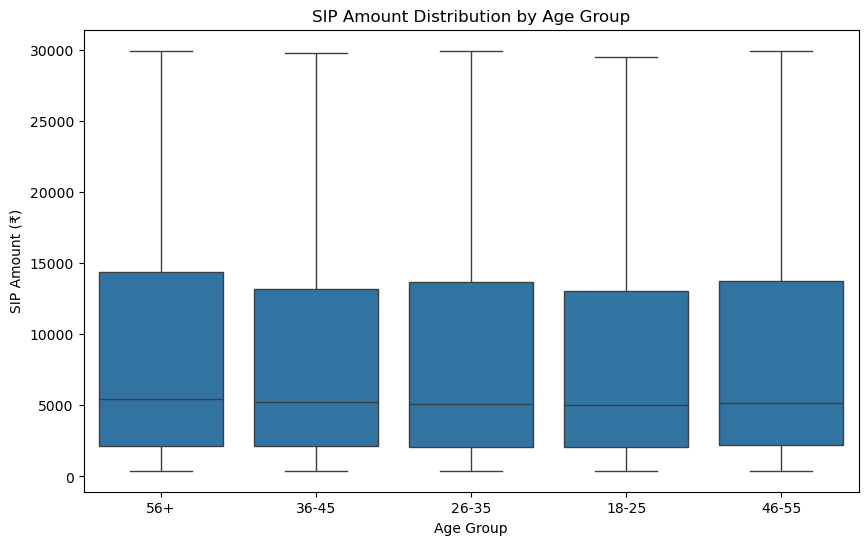

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sip_data = trans[
    trans["transaction_type"] == "Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr",
     showfliers=False

)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.show()

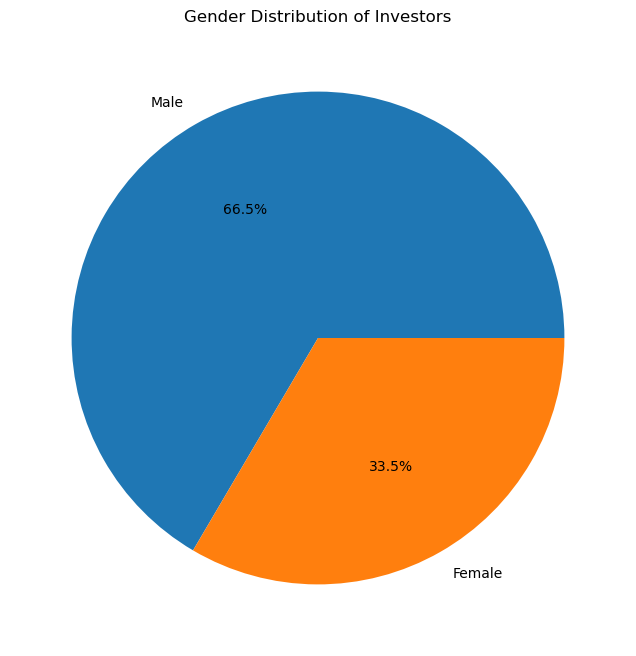

In [16]:
gender_counts = trans["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")
plt.show()

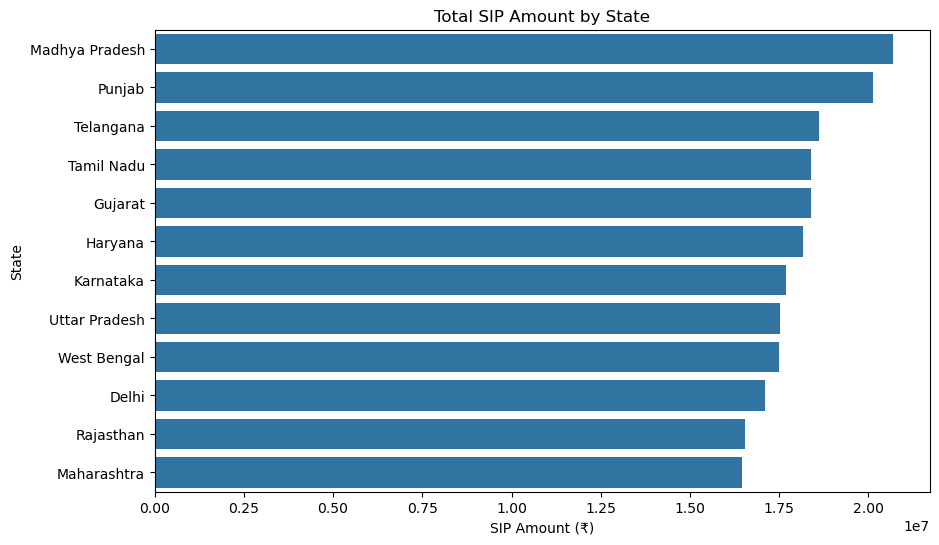

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

trans = pd.read_csv(
    "data/processed/clean_transactions.csv"
)

sip_data = trans[
    trans["transaction_type"] == "Sip"
]

state_sip = (
    sip_data.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")
plt.show()

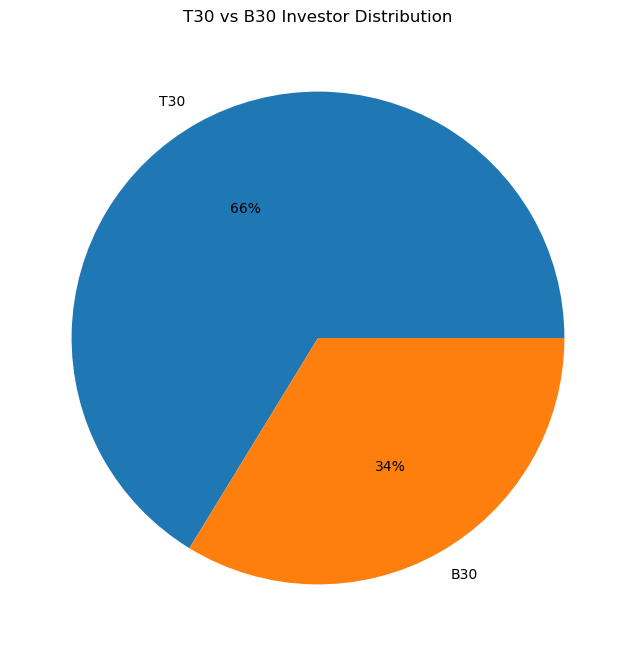

In [19]:
city_counts = trans["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.0f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.show()

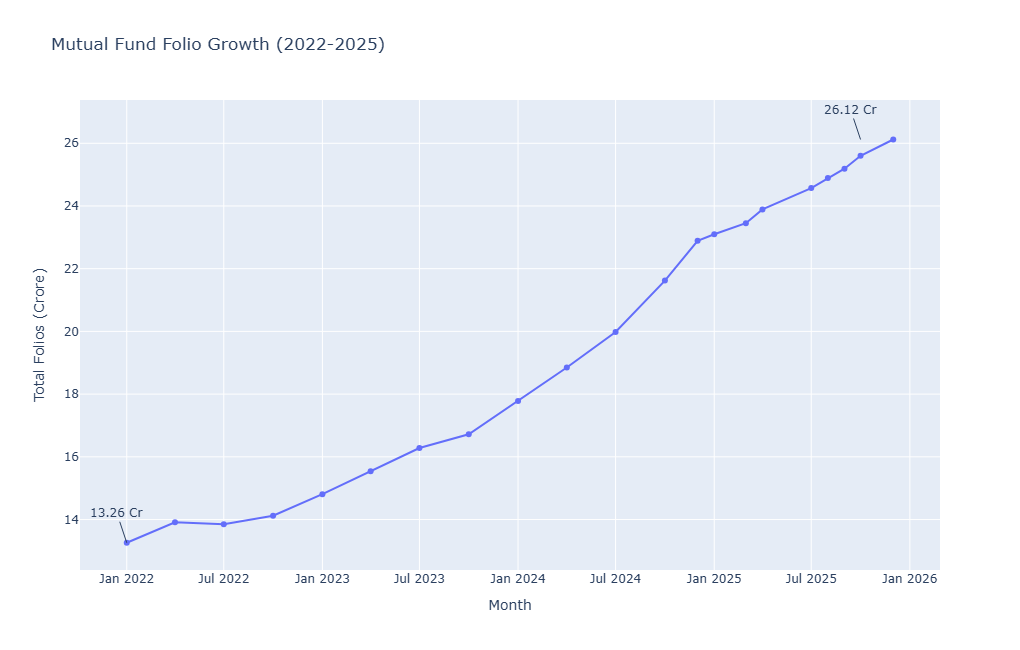

In [21]:
import pandas as pd
import plotly.express as px

folio = pd.read_csv(
    "data/processed/clean_industry_folio_count.csv"
)

folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth (2022-2025)"
)

# Starting point
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr",
    showarrow=True
)

# Ending point
fig.add_annotation(
    x="2025-10-01",
    y=26.12,
    text="26.12 Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    height=650
)

fig.show()
fig.write_image(
    "reports/charts/folio_growth.png"
)

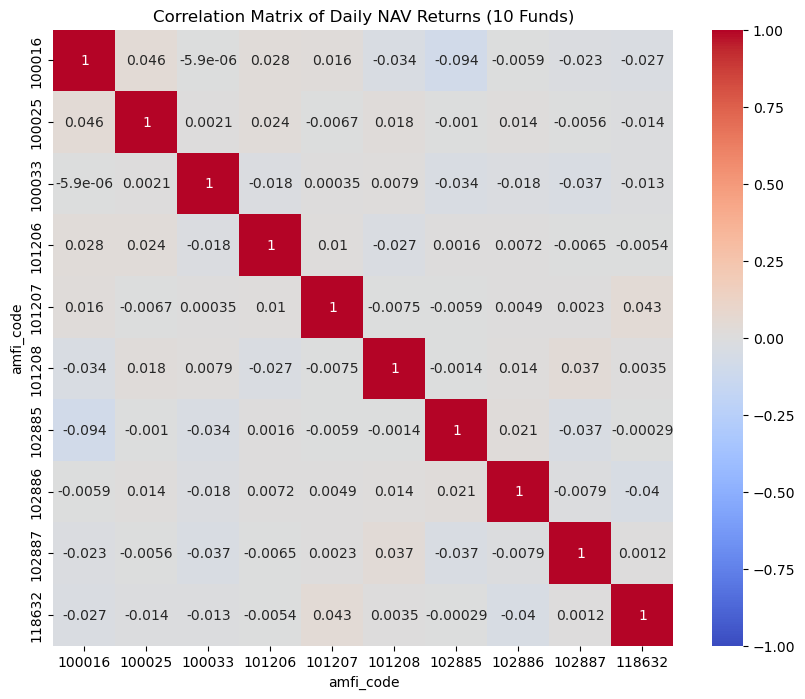

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
nav = pd.read_csv(
    "data/processed/clean_nav.csv"
)
selected_funds = nav["amfi_code"].unique()[:10]

nav_10 = nav[
    nav["amfi_code"].isin(selected_funds)
]

nav_matrix = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_matrix.pct_change()

corr_matrix = returns.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Matrix of Daily NAV Returns (10 Funds)"
)
plt.show()

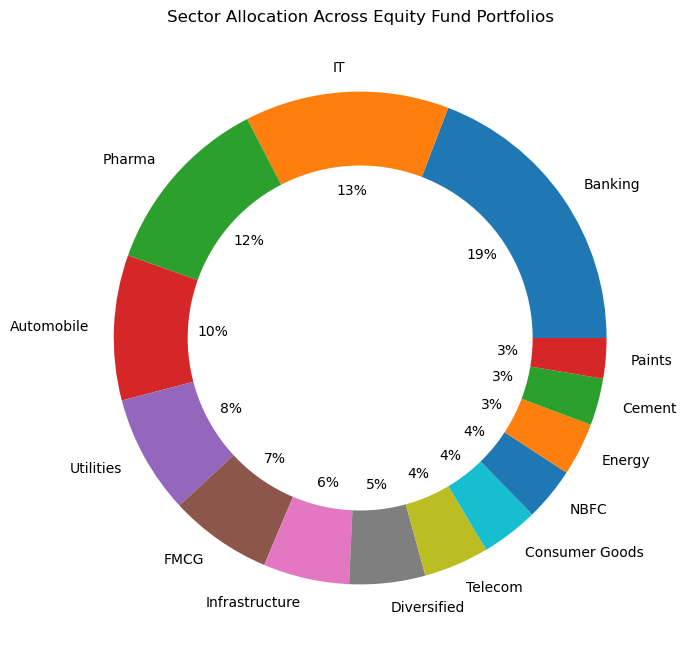

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv(
    "data/processed/clean_portfolio_holdings.csv"
)

sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.0f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

plt.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Fund Portfolios"
)
plt.show()

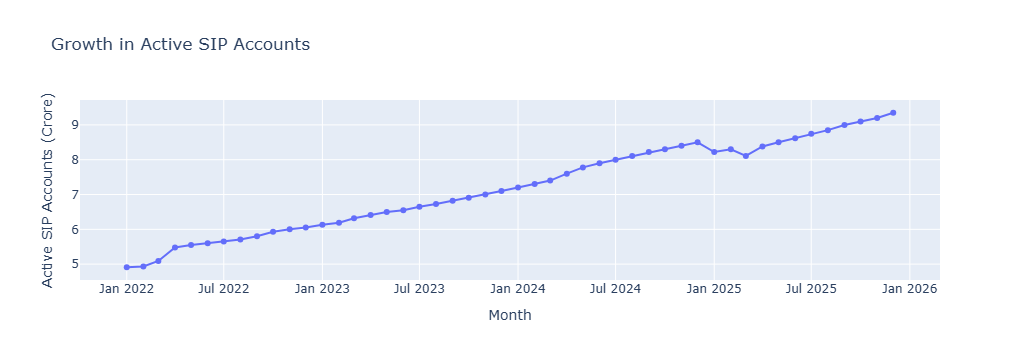

In [25]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv(
    "data/processed/clean_monthly_sip_inflows.csv"
)

sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="active_sip_accounts_crore",
    markers=True,
    title="Growth in Active SIP Accounts"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Active SIP Accounts (Crore)"
)

fig.write_image(
    "reports/charts/active_sip_accounts_growth.png"
)

fig.show()

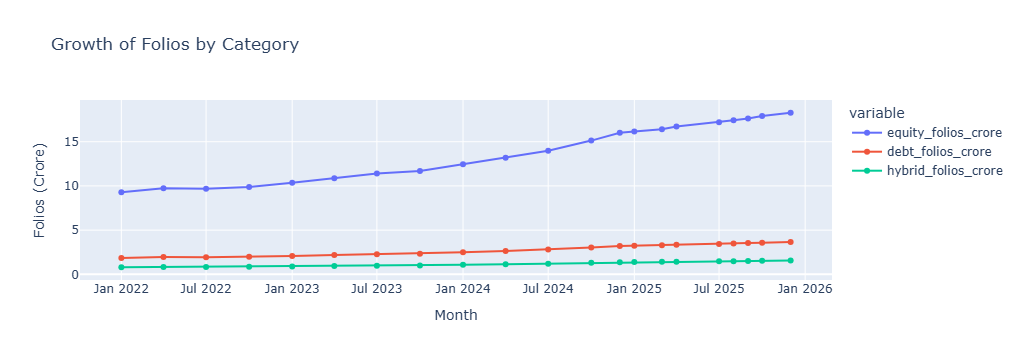

In [26]:
import pandas as pd
import plotly.express as px

folio = pd.read_csv(
    "data/processed/clean_industry_folio_count.csv"
)

folio["month"] = pd.to_datetime(
    folio["month"]
)

fig = px.line(
    folio,
    x="month",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore"
    ],
    markers=True,
    title="Growth of Folios by Category"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Folios (Crore)"
)

fig.write_image(
    "reports/charts/folio_category_growth.png"
)

fig.show()

Key EDA Findings

Finding 1
The overall NAV of mutual fund schemes shows increase from 2022 to 2026 which means indicating long-term growth across the market.

Finding 2
A strong upward trend was visible during 2023 and while 2024 showed some market corrections before growth picked up again.

Finding 3
SBI Mutual Fund consistently remained the largest fund house in terms of AUM and stayed ahead of its competitors throughout the period. 

Finding 4
Monthly SIP inflows grew significantly from around ₹11500 Cr in early 2022 to a record ₹31002 Cr in December 2025, showing increasing investor in mutual funds

Finding 5
Among all fund categories, Liquid Funds received the highest inflows, suggesting that many investors preferred keeping their investments relatively liquid.

Finding 6
The 26–35 age group had the highest number of investors which makes it the most active segment in mutual fund investing.

Finding 7
SIP investment amounts were fairly similar across different age groups, with no major differences in the typical investment amount.

Finding 8
Male investors made up a larger share of the investor base compared to female investors.

Finding 9
Most investors belonged to T30 cities, showing that mutual fund participation is still more concentrated in larger urban areas.

Finding 10
The total number of mutual fund folios increased from 13.26 crore in 2022 to 26.12 crore in 2025 which states that growth in investor over the years